<a href="https://colab.research.google.com/github/Prajnan13/PD-COLLEGE-DEMO/blob/main/Digital_KYC_reduce_drop_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q fpdf openpyxl

  Preparing metadata (setup.py) ... done


In [ ]:
import os, re
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fpdf import FPDF
from google.colab import files

uploading excel file


In [ ]:
print("Please upload your Excel file (e.g. Digital KYC_Reduce Drop-Off_Lift Conversion.xlsx)")
uploaded = files.upload()
if not uploaded:
    raise SystemExit("No file uploaded. Rerun and upload the Excel file.")
fname = list(uploaded.keys())[0]
print("Uploaded:", fname)

Please upload your Excel file (e.g. Digital KYC_Reduce Drop-Off_Lift Conversion.xlsx)


Saving Digital KYC_Reduce Drop-Off_Lift Conversion.xlsx to Digital KYC_Reduce Drop-Off_Lift Conversion.xlsx
Uploaded: Digital KYC_Reduce Drop-Off_Lift Conversion.xlsx


Read Excel with header row = 1

In [ ]:
df_raw = pd.read_excel(fname, header=1)
print("Columns detected:", list(df_raw.columns))
display(df_raw.head(6))

Columns detected: ['Unnamed: 0', 'S.No.', 'Customer ID', 'Stage Name', 'Attempt Count', 'Failure Percentage', 'Time Taken (in seconds)', 'Error']


,Unnamed: 0,S.No.,Customer ID,Stage Name,Attempt Count,Failure Percentage,Time Taken (in seconds),Error
0,NaN,1,2815597,Upload Document,1,0.15,16,Upload the Selected Document
1,NaN,2,2738532,Document Scan,3,0.30,39,Please scan the correct document
2,NaN,3,4110529,Document Scan,2,0.20,25,Please scan the correct document
3,NaN,4,2992473,KYC Check,3,0.30,32,KYC data not found; please upload correct KYC
4,NaN,5,4205534,KYC Approved,1,0.00,15,KYC Successful
5,NaN,6,3980339,Select Document Type,3,0.15,28,Please select correct document type


Cleanning & rename columns


In [ ]:
rename_map = {}
for c in df_raw.columns:
    lc = str(c).strip().lower()
    if 'stage' in lc and 'name' in lc:
        rename_map[c] = 'Stage'
    elif 'attempt' in lc or 'attempt count' in lc:
        rename_map[c] = 'Count'
    elif 'failure' in lc and 'percent' in lc:
        rename_map[c] = 'FailurePercent'
    elif 'time' in lc and 'second' in lc:
        rename_map[c] = 'TimeTaken'
    elif 'error' in lc:
        rename_map[c] = 'ErrorTag'
    else:
        # keep other columns as-is
        rename_map.setdefault(c, c)

df = df_raw.rename(columns=rename_map)

# Keep & coerce useful columns
expected = ['Stage','Count','FailurePercent','TimeTaken','ErrorTag']
present = [c for c in expected if c in df.columns]
print("Using columns:", present)

if 'Count' in present:
    df['Count'] = pd.to_numeric(df['Count'], errors='coerce').fillna(0).astype(int)
if 'TimeTaken' in present:
    df['TimeTaken'] = pd.to_numeric(df['TimeTaken'], errors='coerce')
if 'FailurePercent' in present:
    df['FailurePercent'] = pd.to_numeric(df['FailurePercent'], errors='coerce')
    if df['FailurePercent'].max() <= 1.01:
        df['FailurePercent'] = df['FailurePercent'] * 100
if 'ErrorTag' in present:
    df['ErrorTag'] = df['ErrorTag'].fillna('').astype(str)

display(df.head(8))

Using columns: ['Stage', 'Count', 'FailurePercent', 'TimeTaken', 'ErrorTag']


,Unnamed: 0,S.No.,Customer ID,Stage,Count,FailurePercent,TimeTaken,ErrorTag
0,NaN,1,2815597,Upload Document,1,15.0,16,Upload the Selected Document
1,NaN,2,2738532,Document Scan,3,30.0,39,Please scan the correct document
2,NaN,3,4110529,Document Scan,2,20.0,25,Please scan the correct document
3,NaN,4,2992473,KYC Check,3,30.0,32,KYC data not found; please upload correct KYC
4,NaN,5,4205534,KYC Approved,1,0.0,15,KYC Successful
5,NaN,6,3980339,Select Document Type,3,15.0,28,Please select correct document type
6,NaN,7,3805421,Upload Document,2,40.0,26,Please upload the correct selected document
7,NaN,8,3677810,Document Scan,1,10.0,16,Proceed to Document Upload


Aggregate by Stage

In [ ]:
agg_funcs = {}
if 'Count' in present:
    agg_funcs['Count'] = 'sum'
if 'TimeTaken' in present:
    agg_funcs['TimeTaken'] = 'mean'
if 'FailurePercent' in present:
    agg_funcs['FailurePercent'] = 'mean'

stage_group = df.groupby('Stage', as_index=False).agg(agg_funcs)
if 'TimeTaken' in stage_group.columns:
    stage_group['TimeTaken'] = stage_group['TimeTaken'].round(1)
if 'FailurePercent' in stage_group.columns:
    stage_group['FailurePercent'] = stage_group['FailurePercent'].round(2)

stage_group = stage_group.sort_values(by='Count', ascending=False if 'Count' in stage_group.columns else True).reset_index(drop=True)
print("Stage-level summary:")
display(stage_group)

Stage-level summary:


,Stage,Count,TimeTaken,FailurePercent
0,Document Scan,309,31.6,22.07
1,Upload Document,212,27.6,24.19
2,KYC Check,142,33.2,46.83
3,Select Document Type,137,30.4,11.42
4,KYC Approved,71,27.6,6.25


Error tag analysis

In [ ]:
def split_tags(s):
    if not s or str(s).strip()=='':
        return []
    return [p.strip().lower() for p in re.split(r'[;,/|]', str(s)) if p.strip()]

all_tags = []
if 'ErrorTag' in present:
    for s in df['ErrorTag'].astype(str):
        all_tags += split_tags(s)
tag_counts = pd.Series(all_tags).value_counts().rename_axis('error_tag').reset_index(name='count')
print("Top error tags:")
display(tag_counts.head(15))

Top error tags:


,error_tag,count
0,please scan the correct document,104
1,please upload the correct selected document,59
2,please upload correct kyc,53
3,kyc successful,40
4,please select correct document type,39
5,proceed to document upload,36
6,kyc data not found,34
7,upload the selected document,32
8,kyc document already exists,19
9,aadhar,16


Prepare output folder

In [ ]:
outdir = "kyc_outputs"
os.makedirs(outdir, exist_ok=True)


Plot: Count by Stage

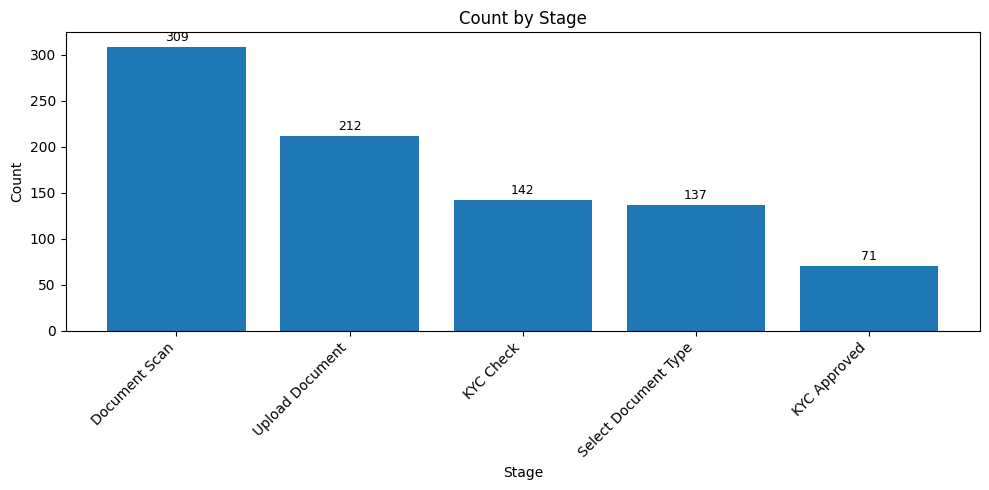

In [ ]:
if 'Count' in stage_group.columns:
    plt.figure(figsize=(10,5))
    bars = plt.bar(stage_group['Stage'], stage_group['Count'])
    plt.title('Count by Stage')
    plt.xlabel('Stage')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    # add labels above bars
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + max(stage_group['Count'])*0.01, f'{int(h)}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    p1 = os.path.join(outdir,"count_by_stage.png")
    plt.savefig(p1)
    plt.show()
else:
    p1 = None

Average Time by Stage with 20s threshold



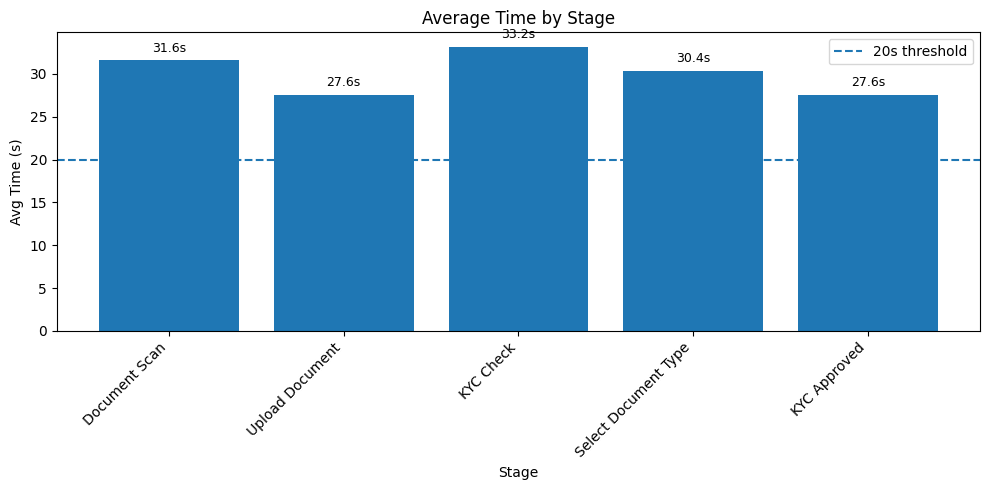

In [ ]:
if 'TimeTaken' in stage_group.columns:
    plt.figure(figsize=(10,5))
    bars = plt.bar(stage_group['Stage'], stage_group['TimeTaken'])
    plt.axhline(20, linestyle='--', label='20s threshold')
    plt.title('Average Time by Stage')
    plt.xlabel('Stage')
    plt.ylabel('Avg Time (s)')
    plt.xticks(rotation=45, ha='right')
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + max(stage_group['TimeTaken'])*0.02, f'{h:.1f}s', ha='center', va='bottom', fontsize=9)
    plt.legend()
    plt.tight_layout()
    p2 = os.path.join(outdir,"avg_time_by_stage.png")
    plt.savefig(p2)
    plt.show()
else:
    p2 = None

Plot: Failure % by Stage

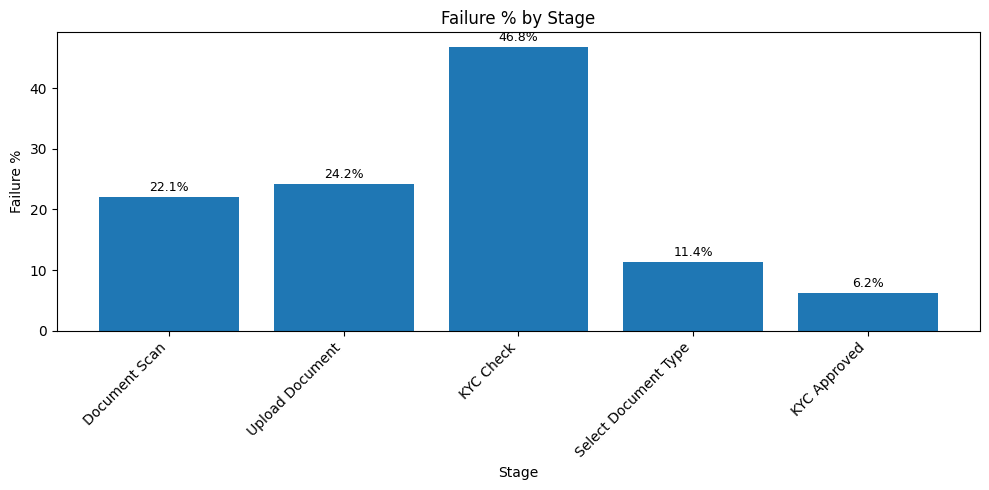

In [ ]:
if 'FailurePercent' in stage_group.columns:
    plt.figure(figsize=(10,5))
    bars = plt.bar(stage_group['Stage'], stage_group['FailurePercent'])
    plt.title('Failure % by Stage')
    plt.xlabel('Stage')
    plt.ylabel('Failure %')
    plt.xticks(rotation=45, ha='right')
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + max(stage_group['FailurePercent'])*0.01, f'{h:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    p4 = os.path.join(outdir,"failurepercent_by_stage.png")
    plt.savefig(p4)
    plt.show()
else:
    p4 = None


Plot: Top Error Tags

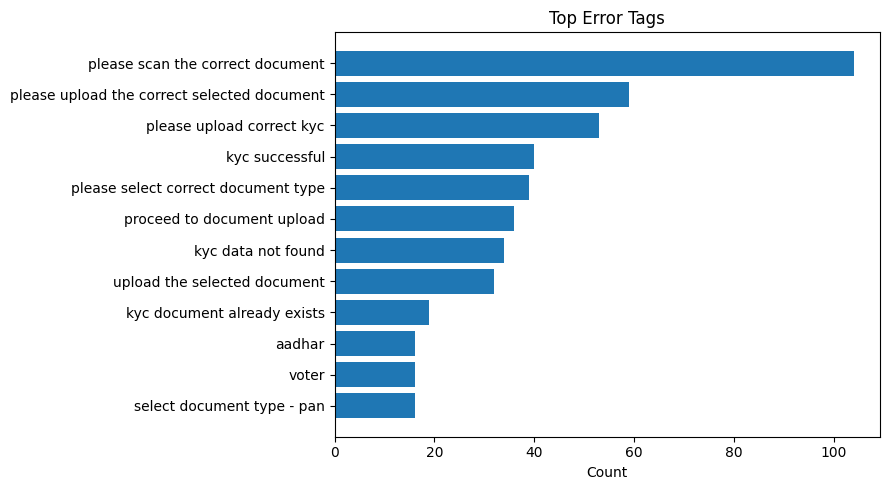

Saved plots: ['kyc_outputs/count_by_stage.png', 'kyc_outputs/avg_time_by_stage.png', 'kyc_outputs/top_error_tags.png', 'kyc_outputs/failurepercent_by_stage.png']


In [ ]:
if not tag_counts.empty:
    top_tags = tag_counts.head(12).sort_values('count')  # sort for horizontal bar
    plt.figure(figsize=(9,5))
    plt.barh(top_tags['error_tag'], top_tags['count'])
    plt.title('Top Error Tags')
    plt.xlabel('Count')
    plt.tight_layout()
    p3 = os.path.join(outdir,"top_error_tags.png")
    plt.savefig(p3)
    plt.show()
else:
    p3 = None

print("Saved plots:", [p for p in (p1,p2,p3,p4) if p])


In [ ]:
stage_group.to_csv(os.path.join(outdir,"stage_summary.csv"), index=False)
tag_counts.to_csv(os.path.join(outdir,"error_tag_counts.csv"), index=False)

In [ ]:
pdf_name = "kyc_summary_report.pdf"
pdf = FPDF()
pdf.set_auto_page_break(True, margin=12)
pdf.add_page()
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 8, "Digital KYC - Funnel Analysis", ln=1)
pdf.set_font("Arial", size=11)
pdf.ln(2)
pdf.multi_cell(0,6, f"Generated: {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}")
pdf.ln(3)

pdf.set_font("Arial", 'B', 12)
pdf.cell(0,6,"Stage Summary:", ln=1)
pdf.set_font("Arial", size=10)
for _, r in stage_group.iterrows():
    line = f"- {r['Stage']}"
    if 'Count' in r:
        line += f" | Count={int(r['Count'])}"
    if 'FailurePercent' in r:
        line += f" | Failure%={r['FailurePercent']}%"
    if 'TimeTaken' in r:
        line += f" | AvgTime={r['TimeTaken']}s"
    pdf.multi_cell(0,6,line)

pdf.add_page()
pdf.set_font("Arial", 'B', 12)
pdf.cell(0,6,"Top Error Tags:", ln=1)
pdf.set_font("Arial", size=10)
for i, row in tag_counts.head(10).iterrows():
    pdf.multi_cell(0,6, f"{i+1}. {row['error_tag']} - {row['count']}")

def add_img(pdf_obj, img_path, title=None):
    if img_path and os.path.exists(img_path):
        pdf_obj.ln(3)
        if title:
            pdf_obj.set_font("Arial", 'B', 11)
            pdf_obj.cell(0,6,title, ln=1)
        pdf_obj.image(img_path, x=12, w=180)
        pdf_obj.ln(4)

add_img(pdf, p1, "Counts by Stage")
add_img(pdf, p2, "Average Time by Stage")
add_img(pdf, p4, "Failure % by Stage")
add_img(pdf, p3, "Top Error Tags")

pdf.output(pdf_name)
print("Generated PDF:", pdf_name)

/tmp/ipython-input-1702943195.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  pdf.multi_cell(0,6, f"Generated: {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}")


Generated PDF: kyc_summary_report.pdf


In [ ]:
files.download(pdf_name)
for fn in os.listdir(outdir):
    files.download(os.path.join(outdir, fn))

print("Done — plots displayed inline and saved in 'kyc_outputs/'.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — plots displayed inline and saved in 'kyc_outputs/'.
